In [1]:
import pandas as pd

master_file = "../raw/climate/ERA5_380006_2005_2024_master.csv"

climate = pd.read_csv(master_file, parse_dates=["date"])
climate["year"] = climate["date"].dt.year

print(climate.shape)
climate.head()

(7305, 5)


,date,ssrd_kwh_m2,temperature_c,precipitation_mm,year
0,2005-01-01,4.718580,17.744920,0.000840,2005
1,2005-01-02,4.738148,18.059627,0.000866,2005
2,2005-01-03,4.826562,18.268463,0.000858,2005
3,2005-01-04,4.724119,19.491347,0.000855,2005
4,2005-01-05,4.668332,19.993656,0.000861,2005


In [2]:
rows_per_year = climate.groupby("year")["date"].count()
print(rows_per_year)

# Expected: 365 for normal years, 366 for leap years (2008, 2012, 2016, 2020, 2024)
leap_years = [2008, 2012, 2016, 2020, 2024]

for year, count in rows_per_year.items():
    expected = 366 if year in leap_years else 365
    status = "OK" if count == expected else "MISMATCH"
    print(f"{year}: {count} rows (expected {expected}) -> {status}")

year
2005    365
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
Name: date, dtype: int64
2005: 365 rows (expected 365) -> OK
2006: 365 rows (expected 365) -> OK
2007: 365 rows (expected 365) -> OK
2008: 366 rows (expected 366) -> OK
2009: 365 rows (expected 365) -> OK
2010: 365 rows (expected 365) -> OK
2011: 365 rows (expected 365) -> OK
2012: 366 rows (expected 366) -> OK
2013: 365 rows (expected 365) -> OK
2014: 365 rows (expected 365) -> OK
2015: 365 rows (expected 365) -> OK
2016: 366 rows (expected 366) -> OK
2017: 365 rows (expected 365) -> OK
2018: 365 rows (expected 365) -> OK
2019: 365 rows (expected 365) -> OK
2020: 366 rows (expected 366) -> OK
2021: 365 rows (expected 365) -> OK
2022: 365 rows (expected 365) -> OK
2023: 365 rows (expected 365) -> OK
2024: 366 rows (expected 366) -> OK


Annual Index

In [3]:
annual_index = (
    climate
    .groupby("year")["ssrd_kwh_m2"]
    .sum()
    .reset_index()
    .rename(columns={"ssrd_kwh_m2": "annual_index_kwh_m2"})
)

print(annual_index)

    year  annual_index_kwh_m2
0   2005          1985.888878
1   2006          1932.798585
2   2007          1961.889860
3   2008          1942.649113
4   2009          2011.017145
5   2010          1950.472437
6   2011          1906.250281
7   2012          1967.640440
8   2013          1891.810662
9   2014          1980.310969
10  2015          1969.048706
11  2016          1909.769859
12  2017          1950.926752
13  2018          1943.577347
14  2019          1886.625109
15  2020          1950.307928
16  2021          1896.020067
17  2022          1974.727071
18  2023          1920.086265
19  2024          1904.948679


In [4]:
print(annual_index["annual_index_kwh_m2"].describe())

# Flag any year that looks out of the expected range
low, high = 1700, 2100  # rough sanity bounds, adjust if needed

out_of_range = annual_index[
    (annual_index["annual_index_kwh_m2"] < low) |
    (annual_index["annual_index_kwh_m2"] > high)
]

print("\nYears outside expected range:")
print(out_of_range if not out_of_range.empty else "None")

count      20.000000
mean     1941.838308
std        34.935990
min      1886.625109
25%      1908.889965
50%      1946.942637
75%      1967.992507
max      2011.017145
Name: annual_index_kwh_m2, dtype: float64

Years outside expected range:
None


In [5]:
# --------------------------------------------------
# Step 3: Baseline and Standard Deviation
# --------------------------------------------------

baseline = annual_index["annual_index_kwh_m2"].mean()
std_dev = annual_index["annual_index_kwh_m2"].std(ddof=1)  # sample std dev (n-1)
coef_variation = (std_dev / baseline) * 100

print(f"Baseline (mean annual index): {baseline:.2f} kWh/m^2/year")
print(f"Standard deviation:           {std_dev:.2f} kWh/m^2/year")
print(f"Coefficient of variation:     {coef_variation:.2f}%")

Baseline (mean annual index): 1941.84 kWh/m^2/year
Standard deviation:           34.94 kWh/m^2/year
Coefficient of variation:     1.80%


In [6]:
# --------------------------------------------------
# Step 4: Deviation of each year from baseline
# --------------------------------------------------

annual_index["deviation_pct"] = (
    (annual_index["annual_index_kwh_m2"] - baseline) / baseline * 100
)

print(annual_index.to_string(index=False))

print(f"\nWorst year: {annual_index.loc[annual_index['deviation_pct'].idxmin(), 'year']} "
      f"({annual_index['deviation_pct'].min():.2f}%)")
print(f"Best year:  {annual_index.loc[annual_index['deviation_pct'].idxmax(), 'year']} "
      f"({annual_index['deviation_pct'].max():.2f}%)")

 year  annual_index_kwh_m2  deviation_pct
 2005          1985.888878       2.268498
 2006          1932.798585      -0.465524
 2007          1961.889860       1.032607
 2008          1942.649113       0.041755
 2009          2011.017145       3.562544
 2010          1950.472437       0.444637
 2011          1906.250281      -1.832698
 2012          1967.640440       1.328748
 2013          1891.810662      -2.576303
 2014          1980.310969       1.981249
 2015          1969.048706       1.401270
 2016          1909.769859      -1.651448
 2017          1950.926752       0.468033
 2018          1943.577347       0.089556
 2019          1886.625109      -2.843347
 2020          1950.307928       0.436165
 2021          1896.020067      -2.359529
 2022          1974.727071       1.693692
 2023          1920.086265      -1.120178
 2024          1904.948679      -1.899727

Worst year: 2019 (-2.84%)
Best year:  2009 (3.56%)


In [7]:
# --------------------------------------------------
# Threshold (std-dev method, k = 1)
# --------------------------------------------------

k = 1
threshold_pct = -(k * std_dev / baseline) * 100

print(f"Threshold (k={k}): {threshold_pct:.2f}%")

triggering_years = annual_index[annual_index["deviation_pct"] < threshold_pct]

print(f"\nYears triggering payout ({len(triggering_years)} out of {len(annual_index)}):")
print(triggering_years[["year", "annual_index_kwh_m2", "deviation_pct"]].to_string(index=False))

payout_frequency = len(triggering_years) / len(annual_index)
print(f"\nHistorical payout frequency: {payout_frequency:.1%} (~1-in-{1/payout_frequency:.1f} years)")

Threshold (k=1): -1.80%

Years triggering payout (5 out of 20):
 year  annual_index_kwh_m2  deviation_pct
 2011          1906.250281      -1.832698
 2013          1891.810662      -2.576303
 2019          1886.625109      -2.843347
 2021          1896.020067      -2.359529
 2024          1904.948679      -1.899727

Historical payout frequency: 25.0% (~1-in-4.0 years)


In [8]:
# --------------------------------------------------
# Threshold (percentile method)
# --------------------------------------------------

# Choose the percentile you want payouts to occur at or below.
# E.g., 25th percentile => roughly worst 1-in-4 years trigger,
# 20th percentile => roughly worst 1-in-5 years trigger.

percentile_choices = [10, 20, 25]

for p in percentile_choices:
    threshold_p = annual_index["deviation_pct"].quantile(p / 100)
    n_triggering = (annual_index["deviation_pct"] < threshold_p).sum()
    freq = n_triggering / len(annual_index)
    print(f"{p}th percentile threshold: {threshold_p:.2f}%  "
          f"-> {n_triggering}/{len(annual_index)} years trigger "
          f"(~1-in-{1/freq:.1f} years)" if freq > 0 else f"{p}th percentile: no years trigger")

10th percentile threshold: -2.38%  -> 2/20 years trigger (~1-in-10.0 years)
20th percentile threshold: -1.85%  -> 4/20 years trigger (~1-in-5.0 years)
25th percentile threshold: -1.70%  -> 5/20 years trigger (~1-in-4.0 years)


In [9]:
# --------------------------------------------------
# Compare std-dev threshold vs percentile thresholds side by side
# --------------------------------------------------

comparison_rows = []

# std-dev method (k=1, from Block 7)
comparison_rows.append({
    "method": "Std-dev (k=1)",
    "threshold_pct": threshold_pct,
    "n_triggering": len(triggering_years),
    "frequency": f"1-in-{len(annual_index)/len(triggering_years):.1f}"
})

# percentile methods
for p in percentile_choices:
    threshold_p = annual_index["deviation_pct"].quantile(p / 100)
    n = (annual_index["deviation_pct"] < threshold_p).sum()
    comparison_rows.append({
        "method": f"{p}th percentile",
        "threshold_pct": threshold_p,
        "n_triggering": n,
        "frequency": f"1-in-{len(annual_index)/n:.1f}" if n > 0 else "N/A"
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

         method  threshold_pct  n_triggering frequency
  Std-dev (k=1)      -1.799119             5  1-in-4.0
10th percentile      -2.381207             2 1-in-10.0
20th percentile      -1.846104             4  1-in-5.0
25th percentile      -1.696760             5  1-in-4.0


In [10]:
# --------------------------------------------------
# Check a round, explainable threshold against the data
# --------------------------------------------------

round_threshold = -2.0

triggering_round = annual_index[annual_index["deviation_pct"] < round_threshold]
freq_round = len(triggering_round) / len(annual_index)

print(f"Round threshold: {round_threshold}%")
print(f"Years triggering ({len(triggering_round)}/{len(annual_index)}):")
print(triggering_round[["year", "annual_index_kwh_m2", "deviation_pct"]].to_string(index=False))
print(f"Frequency: ~1-in-{1/freq_round:.1f} years")

Round threshold: -2.0%
Years triggering (3/20):
 year  annual_index_kwh_m2  deviation_pct
 2013          1891.810662      -2.576303
 2019          1886.625109      -2.843347
 2021          1896.020067      -2.359529
Frequency: ~1-in-6.7 years


In [11]:
# --------------------------------------------------
# Final threshold: 20th percentile (approx. 1-in-5-year event)
# --------------------------------------------------

final_percentile = 20
final_threshold_pct = annual_index["deviation_pct"].quantile(final_percentile / 100)

triggering_final = annual_index[
    annual_index["deviation_pct"] < final_threshold_pct
].copy().sort_values("year").reset_index(drop=True)

print(f"Final threshold ({final_percentile}th percentile): {final_threshold_pct:.2f}%")
print(f"Triggering years ({len(triggering_final)}/{len(annual_index)}, "
      f"~1-in-{len(annual_index)/len(triggering_final):.1f} years):\n")
print(triggering_final[["year", "annual_index_kwh_m2", "deviation_pct"]].to_string(index=False))

Final threshold (20th percentile): -1.85%
Triggering years (4/20, ~1-in-5.0 years):

 year  annual_index_kwh_m2  deviation_pct
 2013          1891.810662      -2.576303
 2019          1886.625109      -2.843347
 2021          1896.020067      -2.359529
 2024          1904.948679      -1.899727


In [12]:
# --------------------------------------------------
# Tiered payout band design
# --------------------------------------------------

# Band boundaries: evenly spaced between threshold and worst observed deviation
worst_observed = annual_index["deviation_pct"].min()

n_bands = 3
band_width = (final_threshold_pct - worst_observed) / n_bands

band_edges = [final_threshold_pct - i * band_width for i in range(n_bands + 1)]
# band_edges[0] = threshold (least severe boundary)
# band_edges[-1] = worst_observed (most severe boundary, before extreme band)

band_payout_pct = [0.40, 0.70, 1.00]  # payout % of Max Payout per band, mild -> severe

print("Band boundaries (deviation %):")
for i in range(n_bands):
    print(f"  Band {i+1}: {band_edges[i]:.2f}% to {band_edges[i+1]:.2f}%  ->  {band_payout_pct[i]*100:.0f}% payout")
print(f"  Band {n_bands+1} (Extreme): beyond {band_edges[-1]:.2f}%  ->  100% payout (capped)")


def assign_band_payout_pct(deviation):
    if deviation >= final_threshold_pct:
        return 0.0  # no trigger
    for i in range(n_bands):
        if band_edges[i] >= deviation > band_edges[i + 1]:
            return band_payout_pct[i]
    return 1.00  # beyond worst observed -> extreme band, capped at 100%


annual_index["band_payout_pct"] = annual_index["deviation_pct"].apply(assign_band_payout_pct)

print("\nFull table with band assignment:")
print(annual_index[["year", "annual_index_kwh_m2", "deviation_pct", "band_payout_pct"]].to_string(index=False))

Band boundaries (deviation %):
  Band 1: -1.85% to -2.18%  ->  40% payout
  Band 2: -2.18% to -2.51%  ->  70% payout
  Band 3: -2.51% to -2.84%  ->  100% payout
  Band 4 (Extreme): beyond -2.84%  ->  100% payout (capped)

Full table with band assignment:
 year  annual_index_kwh_m2  deviation_pct  band_payout_pct
 2005          1985.888878       2.268498              0.0
 2006          1932.798585      -0.465524              0.0
 2007          1961.889860       1.032607              0.0
 2008          1942.649113       0.041755              0.0
 2009          2011.017145       3.562544              0.0
 2010          1950.472437       0.444637              0.0
 2011          1906.250281      -1.832698              0.0
 2012          1967.640440       1.328748              0.0
 2013          1891.810662      -2.576303              1.0
 2014          1980.310969       1.981249              0.0
 2015          1969.048706       1.401270              0.0
 2016          1909.769859      -1.65

In [13]:
# --------------------------------------------------
# Step 1: Maximum Payout (Policy Limit)
# --------------------------------------------------

CAPACITY_KW = 3
PR = 0.80
TARIFF = 5.75  # Rs per kWh

stress_buffer = 1.3
worst_observed_deviation = abs(annual_index["deviation_pct"].min())  # 2.84%
stressed_deviation_pct = worst_observed_deviation * stress_buffer

# Convert stressed % shortfall into energy shortfall, then financial shortfall
max_energy_shortfall = (stressed_deviation_pct / 100) * baseline * CAPACITY_KW * PR
maximum_payout = max_energy_shortfall * TARIFF

print(f"Worst observed deviation: -{worst_observed_deviation:.2f}%")
print(f"Stress buffer applied:    {stress_buffer}x")
print(f"Stressed deviation used:  -{stressed_deviation_pct:.2f}%")
print(f"Max energy shortfall:     {max_energy_shortfall:.2f} kWh")
print(f"Maximum Payout (Policy Limit): Rs {maximum_payout:,.2f}")


# --------------------------------------------------
# Step 2: Final payout per year
# --------------------------------------------------

annual_index["payout_rs"] = annual_index["band_payout_pct"] * maximum_payout

print("\nFinal payout table:")
print(annual_index[["year", "deviation_pct", "band_payout_pct", "payout_rs"]].to_string(index=False))

Worst observed deviation: -2.84%
Stress buffer applied:    1.3x
Stressed deviation used:  -3.70%
Max energy shortfall:     172.27 kWh
Maximum Payout (Policy Limit): Rs 990.52

Final payout table:
 year  deviation_pct  band_payout_pct  payout_rs
 2005       2.268498              0.0   0.000000
 2006      -0.465524              0.0   0.000000
 2007       1.032607              0.0   0.000000
 2008       0.041755              0.0   0.000000
 2009       3.562544              0.0   0.000000
 2010       0.444637              0.0   0.000000
 2011      -1.832698              0.0   0.000000
 2012       1.328748              0.0   0.000000
 2013      -2.576303              1.0 990.524787
 2014       1.981249              0.0   0.000000
 2015       1.401270              0.0   0.000000
 2016      -1.651448              0.0   0.000000
 2017       0.468033              0.0   0.000000
 2018       0.089556              0.0   0.000000
 2019      -2.843347              1.0 990.524787
 2020       0.436165

In [14]:
# --------------------------------------------------
# Burn cost
# --------------------------------------------------

burn_cost = annual_index["payout_rs"].mean()

print(f"Burn cost (average annual payout across 20 years): Rs {burn_cost:,.2f}")

# As a % of Maximum Payout and of expected annual savings, for context
aep50_savings = 4600 * TARIFF
print(f"As % of Maximum Payout:        {burn_cost/maximum_payout*100:.1f}%")
print(f"As % of AEP50 annual savings:  {burn_cost/aep50_savings*100:.2f}%")

Burn cost (average annual payout across 20 years): Rs 153.53
As % of Maximum Payout:        15.5%
As % of AEP50 annual savings:  0.58%


In [15]:
# --------------------------------------------------
# Commercial premium recommendation
# --------------------------------------------------

# Loading accounts for: insurer's operating expenses, profit margin,
# uncertainty/reinsurance cost, and parameter risk (since threshold,
# bands, and stress buffer were all judgment calls on 20 years of data)

loading_pct = 30  # working assumption — stated explicitly as a design choice

commercial_premium = burn_cost * (1 + loading_pct / 100)

print(f"Burn cost:            Rs {burn_cost:,.2f}")
print(f"Loading applied:      {loading_pct}%")
print(f"Commercial premium:   Rs {commercial_premium:,.2f}")

# Context checks
print(f"\nPremium as % of AEP50 annual savings: {commercial_premium/aep50_savings*100:.2f}%")
print(f"Premium as % of Maximum Payout:       {commercial_premium/maximum_payout*100:.1f}%")

Burn cost:            Rs 153.53
Loading applied:      30%
Commercial premium:   Rs 199.59

Premium as % of AEP50 annual savings: 0.75%
Premium as % of Maximum Payout:       20.2%


Sensitivity Check


In [16]:
# --------------------------------------------------
# Monthly sensitivity check
# --------------------------------------------------

climate["month"] = climate["date"].dt.month

# Monthly index: sum of daily ssrd_kwh_m2 within each year-month
monthly_index = (
    climate
    .groupby(["year", "month"])["ssrd_kwh_m2"]
    .sum()
    .reset_index()
    .rename(columns={"ssrd_kwh_m2": "monthly_index_kwh_m2"})
)

print(monthly_index.head(15))
print(f"\nTotal year-month rows: {len(monthly_index)}  (expected: 20 years x 12 months = 240)")

    year  month  monthly_index_kwh_m2
0   2005      1            147.643574
1   2005      2            159.786534
2   2005      3            205.331049
3   2005      4            224.200857
4   2005      5            232.655838
5   2005      6            176.865018
6   2005      7            122.548138
7   2005      8            122.973803
8   2005      9            123.529443
9   2005     10            177.143406
10  2005     11            148.969527
11  2005     12            144.241692
12  2006      1            153.734085
13  2006      2            159.739000
14  2006      3            204.142565

Total year-month rows: 240  (expected: 20 years x 12 months = 240)


In [17]:
# --------------------------------------------------
# Baseline and CoV per calendar month (across 20 years)
# --------------------------------------------------

monthly_stats = (
    monthly_index
    .groupby("month")["monthly_index_kwh_m2"]
    .agg(baseline="mean", std_dev=lambda x: x.std(ddof=1))
    .reset_index()
)

monthly_stats["cov_pct"] = (monthly_stats["std_dev"] / monthly_stats["baseline"]) * 100

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_stats["month_name"] = monthly_stats["month"].apply(lambda m: month_names[m-1])

print(monthly_stats[["month_name", "baseline", "std_dev", "cov_pct"]].to_string(index=False))

print(f"\nAnnual-level CoV (for comparison): {coef_variation:.2f}%")
print(f"Highest monthly CoV: {monthly_stats.loc[monthly_stats['cov_pct'].idxmax(), 'month_name']} "
      f"({monthly_stats['cov_pct'].max():.2f}%)")

month_name   baseline   std_dev   cov_pct
       Jan 150.032989  3.175830  2.116755
       Feb 160.493835  4.249559  2.647802
       Mar 204.752293  4.929250  2.407421
       Apr 217.801558  4.311963  1.979767
       May 228.934955  5.936548  2.593116
       Jun 172.140604 13.150638  7.639475
       Jul 112.619052 12.985800 11.530731
       Aug 108.472628 15.435005 14.229401
       Sep 135.366580 17.069138 12.609566
       Oct 168.008316  8.366826  4.980007
       Nov 144.985036  6.768171  4.668186
       Dec 138.230462  5.941957  4.298587

Annual-level CoV (for comparison): 1.80%
Highest monthly CoV: Aug (14.23%)


In [18]:
# --------------------------------------------------
# Monthly deviation (each month compared to its OWN calendar-month baseline)
# --------------------------------------------------

monthly_index = monthly_index.merge(
    monthly_stats[["month", "baseline"]],
    on="month",
    how="left"
)

monthly_index["deviation_pct"] = (
    (monthly_index["monthly_index_kwh_m2"] - monthly_index["baseline"])
    / monthly_index["baseline"] * 100
)

# Show the 10 worst monthly shortfalls across all 240 year-month observations
worst_months = monthly_index.sort_values("deviation_pct").head(10)
print("10 worst monthly shortfalls (any year, any month):")
print(worst_months[["year", "month", "monthly_index_kwh_m2", "deviation_pct"]].to_string(index=False))

10 worst monthly shortfalls (any year, any month):
 year  month  monthly_index_kwh_m2  deviation_pct
 2019      9             99.483080     -26.508389
 2016      8             81.262640     -25.084658
 2021      9            103.689966     -23.400616
 2020      8             84.155618     -22.417646
 2006      8             86.402200     -20.346541
 2017      7             91.277009     -18.950650
 2013      7             91.404935     -18.837059
 2011      8             90.590562     -16.485326
 2008      6            145.675334     -15.374217
 2010     11            124.687219     -13.999939


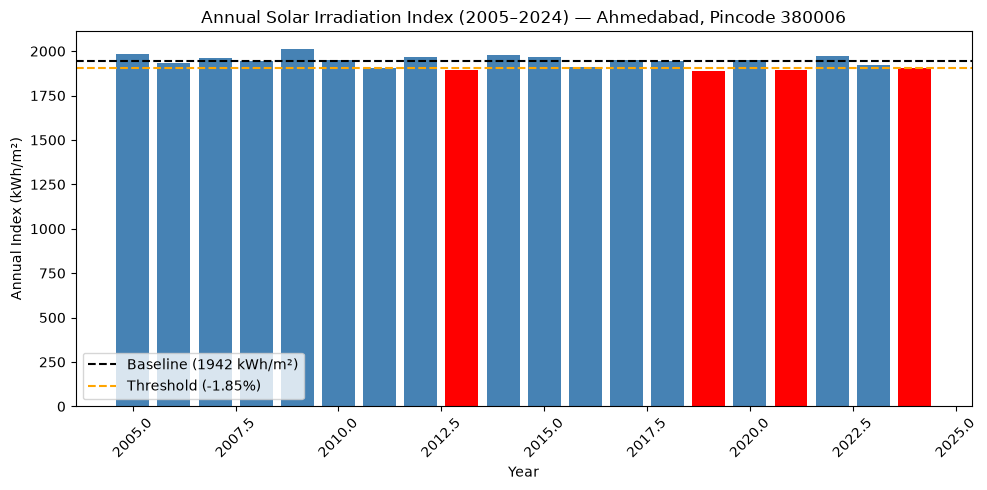

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

colors = ["red" if p > 0 else "steelblue" for p in annual_index["payout_rs"]]
ax.bar(annual_index["year"], annual_index["annual_index_kwh_m2"], color=colors)

ax.axhline(baseline, color="black", linestyle="--", label=f"Baseline ({baseline:.0f} kWh/m²)")
threshold_index_value = baseline * (1 + final_threshold_pct / 100)
ax.axhline(threshold_index_value, color="orange", linestyle="--",
           label=f"Threshold ({final_threshold_pct:.2f}%)")

ax.set_xlabel("Year")
ax.set_ylabel("Annual Index (kWh/m²)")
ax.set_title("Annual Solar Irradiation Index (2005–2024) — Ahmedabad, Pincode 380006")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("annual_index_plot.png", dpi=150)
plt.show()

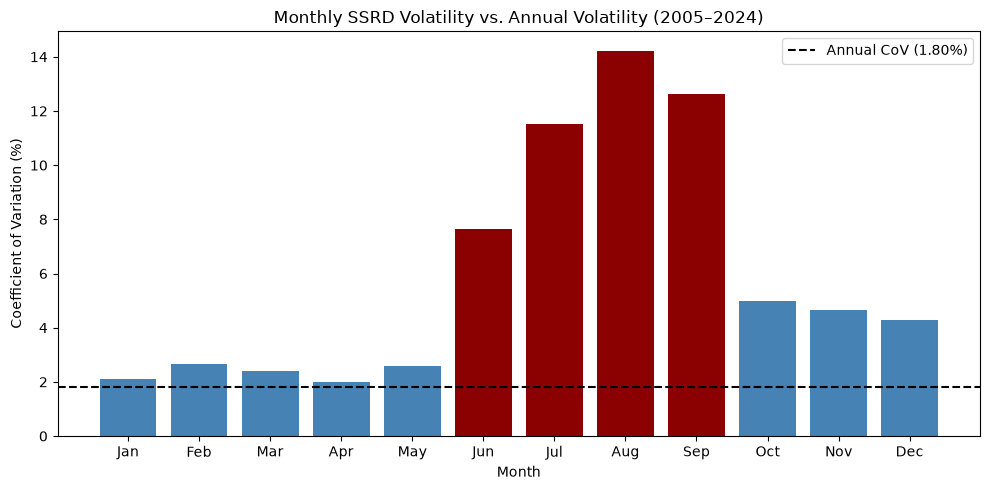

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

monsoon_months = [6, 7, 8, 9]
bar_colors = ["darkred" if m in monsoon_months else "steelblue" for m in monthly_stats["month"]]

ax.bar(monthly_stats["month_name"], monthly_stats["cov_pct"], color=bar_colors)
ax.axhline(coef_variation, color="black", linestyle="--", label=f"Annual CoV ({coef_variation:.2f}%)")

ax.set_xlabel("Month")
ax.set_ylabel("Coefficient of Variation (%)")
ax.set_title("Monthly SSRD Volatility vs. Annual Volatility (2005–2024)")
ax.legend()
plt.tight_layout()
plt.savefig("monthly_cov_plot.png", dpi=150)
plt.show()

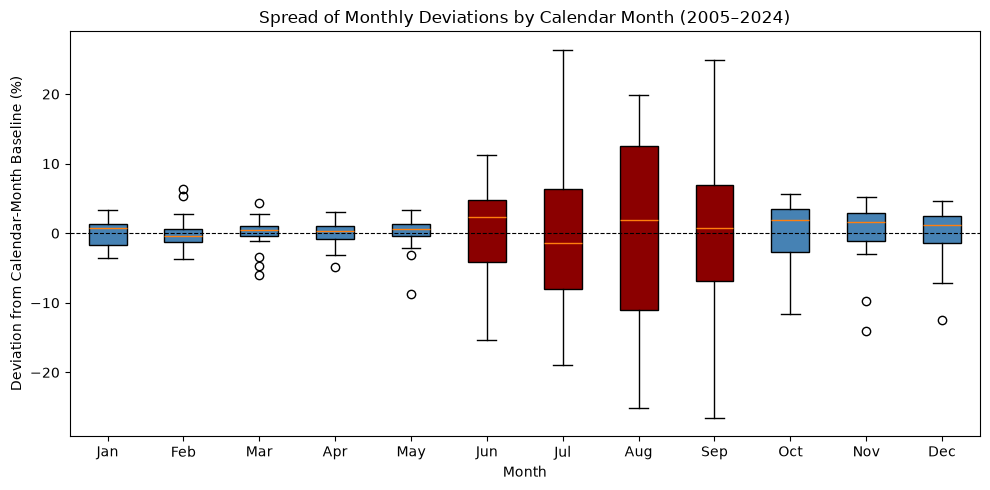

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

month_order = list(range(1, 13))
data_by_month = [
    monthly_index[monthly_index["month"] == m]["deviation_pct"].values
    for m in month_order
]

box = ax.boxplot(data_by_month, tick_labels=month_names, patch_artist=True)

for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor("darkred" if (i + 1) in monsoon_months else "steelblue")

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Month")
ax.set_ylabel("Deviation from Calendar-Month Baseline (%)")
ax.set_title("Spread of Monthly Deviations by Calendar Month (2005–2024)")
plt.tight_layout()
plt.savefig("monthly_boxplot.png", dpi=150)
plt.show()

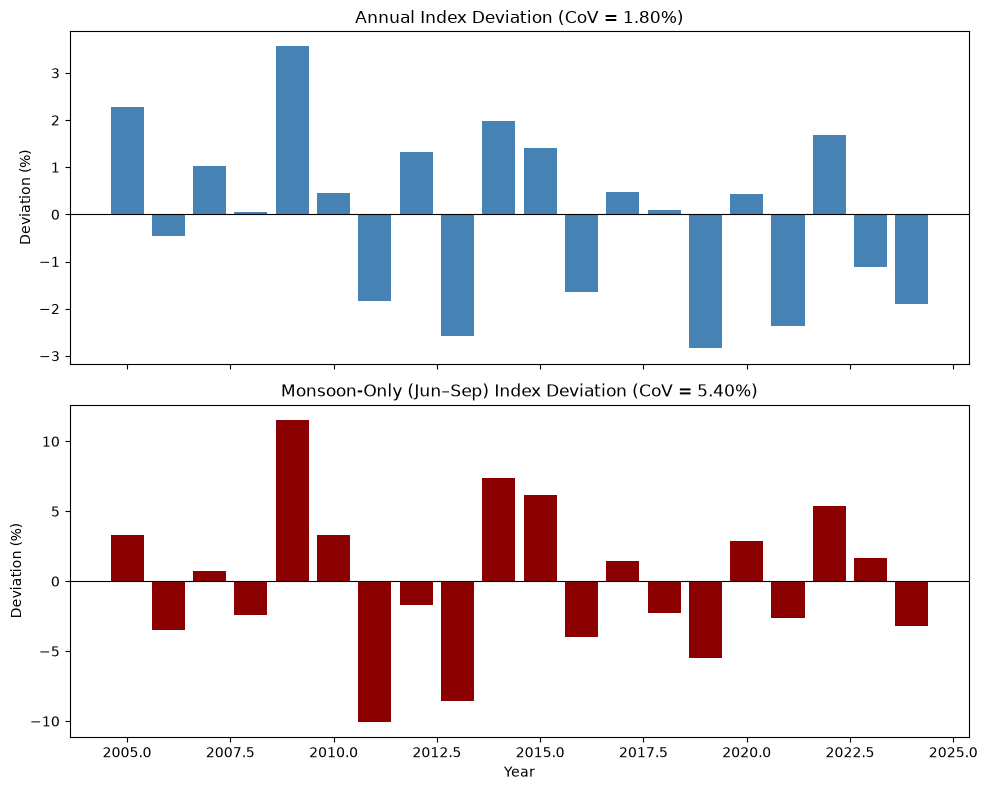

Monsoon-only Baseline: 528.60 kWh/m²
Monsoon-only StdDev:   28.54 kWh/m²
Monsoon-only CoV:      5.40%


In [22]:
# Build the seasonal (monsoon) index for comparison
monsoon_index = (
    climate[climate["month"].isin(monsoon_months)]
    .groupby("year")["ssrd_kwh_m2"]
    .sum()
    .reset_index()
    .rename(columns={"ssrd_kwh_m2": "monsoon_index_kwh_m2"})
)

monsoon_baseline = monsoon_index["monsoon_index_kwh_m2"].mean()
monsoon_std = monsoon_index["monsoon_index_kwh_m2"].std(ddof=1)
monsoon_cov = (monsoon_std / monsoon_baseline) * 100

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].bar(annual_index["year"], annual_index["deviation_pct"], color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Annual Index Deviation (CoV = {coef_variation:.2f}%)")
axes[0].set_ylabel("Deviation (%)")

monsoon_index["deviation_pct"] = (
    (monsoon_index["monsoon_index_kwh_m2"] - monsoon_baseline) / monsoon_baseline * 100
)
axes[1].bar(monsoon_index["year"], monsoon_index["deviation_pct"], color="darkred")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Monsoon-Only (Jun–Sep) Index Deviation (CoV = {monsoon_cov:.2f}%)")
axes[1].set_ylabel("Deviation (%)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("annual_vs_monsoon_deviation.png", dpi=150)
plt.show()

print(f"Monsoon-only Baseline: {monsoon_baseline:.2f} kWh/m²")
print(f"Monsoon-only StdDev:   {monsoon_std:.2f} kWh/m²")
print(f"Monsoon-only CoV:      {monsoon_cov:.2f}%")

In [23]:
# --------------------------------------------------
# Convert each calendar month's SSRD baseline into energy (kWh)
# --------------------------------------------------

CAPACITY_KW = 3
PR = 0.80

monthly_stats["baseline_energy_kwh"] = (
    monthly_stats["baseline"] * CAPACITY_KW * PR
)

print("Monthly baseline SSRD -> Energy:")
print(monthly_stats[["month_name", "baseline", "baseline_energy_kwh"]].to_string(index=False))

total_annual_energy_from_monthly = monthly_stats["baseline_energy_kwh"].sum()

print(f"\nSum of monthly baseline energy (Jan-Dec): {total_annual_energy_from_monthly:.2f} kWh")
print(f"Given AEP50 (case study):                  4600.00 kWh")
print(f"Annual-index-derived energy (baseline x 3 x 0.80): {baseline * CAPACITY_KW * PR:.2f} kWh")

Monthly baseline SSRD -> Energy:
month_name   baseline  baseline_energy_kwh
       Jan 150.032989           360.079174
       Feb 160.493835           385.185204
       Mar 204.752293           491.405504
       Apr 217.801558           522.723739
       May 228.934955           549.443891
       Jun 172.140604           413.137449
       Jul 112.619052           270.285726
       Aug 108.472628           260.334308
       Sep 135.366580           324.879792
       Oct 168.008316           403.219958
       Nov 144.985036           347.964086
       Dec 138.230462           331.753108

Sum of monthly baseline energy (Jan-Dec): 4660.41 kWh
Given AEP50 (case study):                  4600.00 kWh
Annual-index-derived energy (baseline x 3 x 0.80): 4660.41 kWh


In [24]:
# --------------------------------------------------
# Per-year, per-month energy using actual (not baseline) monthly SSRD
# --------------------------------------------------

monthly_index["energy_kwh"] = (
    monthly_index["monthly_index_kwh_m2"] * CAPACITY_KW * PR
)

print(monthly_index[["year", "month", "monthly_index_kwh_m2", "energy_kwh"]].head(15))

# Monsoon-only (Jun-Sep) energy per year
monsoon_energy_per_year = (
    monthly_index[monthly_index["month"].isin([6, 7, 8, 9])]
    .groupby("year")["energy_kwh"]
    .sum()
    .reset_index()
    .rename(columns={"energy_kwh": "monsoon_energy_kwh"})
)

print("\nMonsoon-season (Jun-Sep) energy generated per year:")
print(monsoon_energy_per_year.to_string(index=False))

monsoon_energy_baseline = monsoon_energy_per_year["monsoon_energy_kwh"].mean()
print(f"\nMonsoon-season expected (baseline) energy: {monsoon_energy_baseline:.2f} kWh")

    year  month  monthly_index_kwh_m2  energy_kwh
0   2005      1            147.643574  354.344579
1   2005      2            159.786534  383.487681
2   2005      3            205.331049  492.794517
3   2005      4            224.200857  538.082056
4   2005      5            232.655838  558.374011
5   2005      6            176.865018  424.476043
6   2005      7            122.548138  294.115532
7   2005      8            122.973803  295.137128
8   2005      9            123.529443  296.470662
9   2005     10            177.143406  425.144173
10  2005     11            148.969527  357.526864
11  2005     12            144.241692  346.180061
12  2006      1            153.734085  368.961804
13  2006      2            159.739000  383.373600
14  2006      3            204.142565  489.942157

Monsoon-season (Jun-Sep) energy generated per year:
 year  monsoon_energy_kwh
 2005         1310.199365
 2006         1224.273698
 2007         1277.605933
 2008         1238.142653
 2009         141

In [25]:
# --------------------------------------------------
# Monsoon-season energy: deviation, std dev, threshold
# --------------------------------------------------

TARIFF = 5.75

monsoon_energy_baseline = monsoon_energy_per_year["monsoon_energy_kwh"].mean()
monsoon_energy_std = monsoon_energy_per_year["monsoon_energy_kwh"].std(ddof=1)
monsoon_energy_cov = (monsoon_energy_std / monsoon_energy_baseline) * 100

monsoon_energy_per_year["deviation_pct"] = (
    (monsoon_energy_per_year["monsoon_energy_kwh"] - monsoon_energy_baseline)
    / monsoon_energy_baseline * 100
)

print(f"Monsoon energy baseline: {monsoon_energy_baseline:.2f} kWh")
print(f"Monsoon energy std dev:  {monsoon_energy_std:.2f} kWh")
print(f"Monsoon energy CoV:      {monsoon_energy_cov:.2f}%")
print()
print(monsoon_energy_per_year[["year", "monsoon_energy_kwh", "deviation_pct"]].to_string(index=False))

Monsoon energy baseline: 1268.64 kWh
Monsoon energy std dev:  68.49 kWh
Monsoon energy CoV:      5.40%

 year  monsoon_energy_kwh  deviation_pct
 2005         1310.199365       3.276121
 2006         1224.273698      -3.496947
 2007         1277.605933       0.706952
 2008         1238.142653      -2.403731
 2009         1414.985347      11.535848
 2010         1310.239275       3.279267
 2011         1141.093147     -10.053632
 2012         1247.008398      -1.704890
 2013         1159.860363      -8.574312
 2014         1362.644880       7.410125
 2015         1346.883622       6.167748
 2016         1218.259475      -3.971017
 2017         1287.203210       1.463455
 2018         1240.076686      -2.251281
 2019         1199.338497      -5.462458
 2020         1305.150677       2.878159
 2021         1234.817164      -2.665861
 2022         1337.028452       5.390917
 2023         1289.804071       1.668467
 2024         1228.130578      -3.192930


In [26]:
# --------------------------------------------------
# Threshold (20th percentile, consistent with your annual-index choice)
# --------------------------------------------------

final_percentile = 20
monsoon_threshold_pct = monsoon_energy_per_year["deviation_pct"].quantile(final_percentile / 100)

triggering_monsoon = monsoon_energy_per_year[
    monsoon_energy_per_year["deviation_pct"] < monsoon_threshold_pct
].sort_values("year").reset_index(drop=True)

print(f"Threshold ({final_percentile}th percentile): {monsoon_threshold_pct:.2f}%")
print(f"Triggering years ({len(triggering_monsoon)}/{len(monsoon_energy_per_year)}, "
      f"~1-in-{len(monsoon_energy_per_year)/len(triggering_monsoon):.1f} years):\n")
print(triggering_monsoon[["year", "monsoon_energy_kwh", "deviation_pct"]].to_string(index=False))

Threshold (20th percentile): -3.59%
Triggering years (4/20, ~1-in-5.0 years):

 year  monsoon_energy_kwh  deviation_pct
 2011         1141.093147     -10.053632
 2013         1159.860363      -8.574312
 2016         1218.259475      -3.971017
 2019         1199.338497      -5.462458


In [27]:
# --------------------------------------------------
# Tiered payout bands (same 3-band style as before, rebuilt on monsoon energy)
# --------------------------------------------------

worst_observed_dev = monsoon_energy_per_year["deviation_pct"].min()

n_bands = 3
band_width = (monsoon_threshold_pct - worst_observed_dev) / n_bands
band_edges = [monsoon_threshold_pct - i * band_width for i in range(n_bands + 1)]
band_payout_pct = [0.40, 0.70, 1.00]

print("Band boundaries (deviation %):")
for i in range(n_bands):
    print(f"  Band {i+1}: {band_edges[i]:.2f}% to {band_edges[i+1]:.2f}%  ->  {band_payout_pct[i]*100:.0f}% payout")
print(f"  Band {n_bands+1} (Extreme): beyond {band_edges[-1]:.2f}%  ->  100% payout (capped)")


def assign_band_payout_pct(deviation):
    if deviation >= monsoon_threshold_pct:
        return 0.0
    for i in range(n_bands):
        if band_edges[i] >= deviation > band_edges[i + 1]:
            return band_payout_pct[i]
    return 1.00


monsoon_energy_per_year["band_payout_pct"] = (
    monsoon_energy_per_year["deviation_pct"].apply(assign_band_payout_pct)
)

print("\nFull table with band assignment:")
print(monsoon_energy_per_year[["year", "monsoon_energy_kwh", "deviation_pct", "band_payout_pct"]].to_string(index=False))

Band boundaries (deviation %):
  Band 1: -3.59% to -5.75%  ->  40% payout
  Band 2: -5.75% to -7.90%  ->  70% payout
  Band 3: -7.90% to -10.05%  ->  100% payout
  Band 4 (Extreme): beyond -10.05%  ->  100% payout (capped)

Full table with band assignment:
 year  monsoon_energy_kwh  deviation_pct  band_payout_pct
 2005         1310.199365       3.276121              0.0
 2006         1224.273698      -3.496947              0.0
 2007         1277.605933       0.706952              0.0
 2008         1238.142653      -2.403731              0.0
 2009         1414.985347      11.535848              0.0
 2010         1310.239275       3.279267              0.0
 2011         1141.093147     -10.053632              1.0
 2012         1247.008398      -1.704890              0.0
 2013         1159.860363      -8.574312              1.0
 2014         1362.644880       7.410125              0.0
 2015         1346.883622       6.167748              0.0
 2016         1218.259475      -3.971017       

In [28]:
# --------------------------------------------------
# Maximum Payout (grounded directly in energy shortfall, stress-buffered)
# --------------------------------------------------

stress_buffer = 1.3
worst_observed_shortfall_kwh = monsoon_energy_baseline - monsoon_energy_per_year["monsoon_energy_kwh"].min()
stressed_shortfall_kwh = worst_observed_shortfall_kwh * stress_buffer

maximum_payout = stressed_shortfall_kwh * TARIFF

print(f"Worst observed shortfall: {worst_observed_shortfall_kwh:.2f} kWh")
print(f"Stress buffer applied:    {stress_buffer}x")
print(f"Stressed shortfall:       {stressed_shortfall_kwh:.2f} kWh")
print(f"Maximum Payout (Policy Limit): Rs {maximum_payout:,.2f}")


# --------------------------------------------------
# Final payout per year + burn cost
# --------------------------------------------------

monsoon_energy_per_year["payout_rs"] = (
    monsoon_energy_per_year["band_payout_pct"] * maximum_payout
)

burn_cost = monsoon_energy_per_year["payout_rs"].mean()

print("\nFinal payout table:")
print(monsoon_energy_per_year[["year", "deviation_pct", "band_payout_pct", "payout_rs"]].to_string(index=False))

print(f"\nBurn cost: Rs {burn_cost:,.2f}")
print(f"Burn cost as % of Maximum Payout: {burn_cost/maximum_payout*100:.1f}%")

aep50_savings = 4600 * TARIFF
print(f"Burn cost as % of AEP50 annual savings: {burn_cost/aep50_savings*100:.2f}%")

Worst observed shortfall: 127.54 kWh
Stress buffer applied:    1.3x
Stressed shortfall:       165.81 kWh
Maximum Payout (Policy Limit): Rs 953.39

Final payout table:
 year  deviation_pct  band_payout_pct  payout_rs
 2005       3.276121              0.0    0.00000
 2006      -3.496947              0.0    0.00000
 2007       0.706952              0.0    0.00000
 2008      -2.403731              0.0    0.00000
 2009      11.535848              0.0    0.00000
 2010       3.279267              0.0    0.00000
 2011     -10.053632              1.0  953.39235
 2012      -1.704890              0.0    0.00000
 2013      -8.574312              1.0  953.39235
 2014       7.410125              0.0    0.00000
 2015       6.167748              0.0    0.00000
 2016      -3.971017              0.4  381.35694
 2017       1.463455              0.0    0.00000
 2018      -2.251281              0.0    0.00000
 2019      -5.462458              0.4  381.35694
 2020       2.878159              0.0    0.00000


In [29]:
# --------------------------------------------------
# Historical min/max payout — Annual-index version
# --------------------------------------------------

print("ANNUAL-INDEX PAYOUT SUMMARY")
print(f"Minimum payout (including non-triggering years): Rs {annual_index['payout_rs'].min():,.2f}")
print(f"Maximum payout observed:                         Rs {annual_index['payout_rs'].max():,.2f}")

triggering_only = annual_index[annual_index['payout_rs'] > 0]
print(f"\nAmong triggering years only ({len(triggering_only)} years):")
print(f"Minimum non-zero payout: Rs {triggering_only['payout_rs'].min():,.2f} "
      f"(Year: {triggering_only.loc[triggering_only['payout_rs'].idxmin(), 'year']})")
print(f"Maximum payout:          Rs {triggering_only['payout_rs'].max():,.2f} "
      f"(Year: {triggering_only.loc[triggering_only['payout_rs'].idxmax(), 'year']})")

ANNUAL-INDEX PAYOUT SUMMARY
Minimum payout (including non-triggering years): Rs 0.00
Maximum payout observed:                         Rs 990.52

Among triggering years only (4 years):
Minimum non-zero payout: Rs 396.21 (Year: 2024)
Maximum payout:          Rs 990.52 (Year: 2013)


In [30]:
# --------------------------------------------------
# Historical min/max payout — Monsoon-energy version
# --------------------------------------------------

print("MONSOON-ENERGY PAYOUT SUMMARY")
print(f"Minimum payout (including non-triggering years): Rs {monsoon_energy_per_year['payout_rs'].min():,.2f}")
print(f"Maximum payout observed:                         Rs {monsoon_energy_per_year['payout_rs'].max():,.2f}")

triggering_only_monsoon = monsoon_energy_per_year[monsoon_energy_per_year['payout_rs'] > 0]
print(f"\nAmong triggering years only ({len(triggering_only_monsoon)} years):")
print(f"Minimum non-zero payout: Rs {triggering_only_monsoon['payout_rs'].min():,.2f} "
      f"(Year: {triggering_only_monsoon.loc[triggering_only_monsoon['payout_rs'].idxmin(), 'year']})")
print(f"Maximum payout:          Rs {triggering_only_monsoon['payout_rs'].max():,.2f} "
      f"(Year: {triggering_only_monsoon.loc[triggering_only_monsoon['payout_rs'].idxmax(), 'year']})")

MONSOON-ENERGY PAYOUT SUMMARY
Minimum payout (including non-triggering years): Rs 0.00
Maximum payout observed:                         Rs 953.39

Among triggering years only (4 years):
Minimum non-zero payout: Rs 381.36 (Year: 2016)
Maximum payout:          Rs 953.39 (Year: 2011)


In [31]:
# --------------------------------------------------
# Version 1: Monsoon-triggered, AEP50-sized payout
# --------------------------------------------------

AEP50 = 4600  # kWh/year, as given in the case study
TARIFF = 5.75

# Reuse the monsoon deviation series and threshold/bands already computed
# (monsoon_threshold_pct, band_edges, band_payout_pct, band_payout_pct column
#  in monsoon_energy_per_year are already built from earlier steps)

# --------------------------------------------------
# Step 1: Maximum Payout, using AEP50 as the energy base
# --------------------------------------------------

stress_buffer = 1.3
worst_observed_monsoon_dev = abs(monsoon_energy_per_year["deviation_pct"].min())  # 10.05%
stressed_monsoon_dev = worst_observed_monsoon_dev * stress_buffer

max_energy_shortfall = (stressed_monsoon_dev / 100) * AEP50
maximum_payout_v2 = max_energy_shortfall * TARIFF

print(f"Worst observed monsoon deviation: -{worst_observed_monsoon_dev:.2f}%")
print(f"Stress buffer applied:            {stress_buffer}x")
print(f"Stressed deviation used:          -{stressed_monsoon_dev:.2f}%")
print(f"Max energy shortfall (on AEP50):  {max_energy_shortfall:.2f} kWh")
print(f"Maximum Payout (Policy Limit):    Rs {maximum_payout_v2:,.2f}")


# --------------------------------------------------
# Step 2: Per-year payout, using existing monsoon band assignment
# --------------------------------------------------

monsoon_energy_per_year["payout_rs_v2"] = (
    monsoon_energy_per_year["band_payout_pct"] * maximum_payout_v2
)

print("\nFinal payout table (Version 1 — AEP50-sized):")
print(monsoon_energy_per_year[["year", "deviation_pct", "band_payout_pct", "payout_rs_v2"]].to_string(index=False))


# --------------------------------------------------
# Step 3: Burn cost and premium
# --------------------------------------------------

burn_cost_v2 = monsoon_energy_per_year["payout_rs_v2"].mean()
loading_pct = 30
commercial_premium_v2 = burn_cost_v2 * (1 + loading_pct / 100)

aep50_savings = AEP50 * TARIFF

print(f"\nBurn cost:          Rs {burn_cost_v2:,.2f}")
print(f"Commercial premium: Rs {commercial_premium_v2:,.2f}")
print(f"Premium as % of AEP50 annual savings: {commercial_premium_v2/aep50_savings*100:.2f}%")
print(f"Premium as % of Maximum Payout:       {commercial_premium_v2/maximum_payout_v2*100:.1f}%")

Worst observed monsoon deviation: -10.05%
Stress buffer applied:            1.3x
Stressed deviation used:          -13.07%
Max energy shortfall (on AEP50):  601.21 kWh
Maximum Payout (Policy Limit):    Rs 3,456.94

Final payout table (Version 1 — AEP50-sized):
 year  deviation_pct  band_payout_pct  payout_rs_v2
 2005       3.276121              0.0      0.000000
 2006      -3.496947              0.0      0.000000
 2007       0.706952              0.0      0.000000
 2008      -2.403731              0.0      0.000000
 2009      11.535848              0.0      0.000000
 2010       3.279267              0.0      0.000000
 2011     -10.053632              1.0   3456.941473
 2012      -1.704890              0.0      0.000000
 2013      -8.574312              1.0   3456.941473
 2014       7.410125              0.0      0.000000
 2015       6.167748              0.0      0.000000
 2016      -3.971017              0.4   1382.776589
 2017       1.463455              0.0      0.000000
 2018      

In [32]:
# --------------------------------------------------
# Reusable function: build one coverage tier
# --------------------------------------------------

def build_coverage_tier(monsoon_df, percentile, stress_buffer, aep50, tariff,
                         band_payout_pct=(0.40, 0.70, 1.00), loading_pct=30):

    df = monsoon_df.copy()

    # Threshold from chosen percentile
    threshold_pct = df["deviation_pct"].quantile(percentile / 100)

    # Band edges (evenly spaced between threshold and worst observed deviation)
    worst_observed = df["deviation_pct"].min()
    n_bands = len(band_payout_pct)
    band_width = (threshold_pct - worst_observed) / n_bands
    band_edges = [threshold_pct - i * band_width for i in range(n_bands + 1)]

    def assign_band(deviation):
        if deviation >= threshold_pct:
            return 0.0
        for i in range(n_bands):
            if band_edges[i] >= deviation > band_edges[i + 1]:
                return band_payout_pct[i]
        return band_payout_pct[-1]

    df["band_payout_pct"] = df["deviation_pct"].apply(assign_band)

    # Maximum Payout, sized against AEP50 (Version 1 logic)
    stressed_dev = abs(worst_observed) * stress_buffer
    max_energy_shortfall = (stressed_dev / 100) * aep50
    maximum_payout = max_energy_shortfall * tariff

    # Per-year payout
    df["payout_rs"] = df["band_payout_pct"] * maximum_payout

    # Burn cost and premium
    burn_cost = df["payout_rs"].mean()
    premium = burn_cost * (1 + loading_pct / 100)

    n_triggering = (df["band_payout_pct"] > 0).sum()

    return {
        "threshold_pct": threshold_pct,
        "maximum_payout": maximum_payout,
        "burn_cost": burn_cost,
        "premium": premium,
        "n_triggering": n_triggering,
        "payout_table": df
    }


# --------------------------------------------------
# Define the three tiers
# --------------------------------------------------

AEP50 = 4600
TARIFF = 5.75

tier_configs = {
    "Minimal":       {"percentile": 10, "stress_buffer": 1.2},
    "Moderate":      {"percentile": 20, "stress_buffer": 1.3},
    "Comprehensive": {"percentile": 25, "stress_buffer": 1.8},
}

results = {}
for tier_name, cfg in tier_configs.items():
    results[tier_name] = build_coverage_tier(
        monsoon_energy_per_year,
        percentile=cfg["percentile"],
        stress_buffer=cfg["stress_buffer"],
        aep50=AEP50,
        tariff=TARIFF
    )


# --------------------------------------------------
# Summary comparison table
# --------------------------------------------------

aep50_savings = AEP50 * TARIFF

summary_rows = []
for tier_name, res in results.items():
    summary_rows.append({
        "Tier": tier_name,
        "Threshold (%)": round(res["threshold_pct"], 2),
        "Years Triggering": f"{res['n_triggering']}/20",
        "Max Payout (Rs)": round(res["maximum_payout"], 2),
        "Burn Cost (Rs)": round(res["burn_cost"], 2),
        "Premium (Rs)": round(res["premium"], 2),
        "Premium as % of AEP50 Savings": round(res["premium"] / aep50_savings * 100, 2),
        "Premium as % of Max Payout": round(res["premium"] / res["maximum_payout"] * 100, 1),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

         Tier  Threshold (%) Years Triggering  Max Payout (Rs)  Burn Cost (Rs)  Premium (Rs)  Premium as % of AEP50 Savings  Premium as % of Max Payout
      Minimal          -5.77             2/20          3191.02          271.24        352.61                           1.33                        11.0
     Moderate          -3.59             4/20          3456.94          483.97        629.16                           2.38                        18.2
Comprehensive          -3.27             5/20          4786.53          765.85        995.60                           3.76                        20.8


In [33]:
# --------------------------------------------------
# Merge monsoon (trigger signal) with annual (payout sizing)
# --------------------------------------------------

TARIFF = 5.75
CAPACITY_KW = 3
PR = 0.80

# annual_index already has: year, annual_index_kwh_m2, deviation_pct (annual)
# monsoon_energy_per_year already has: year, monsoon_energy_kwh, deviation_pct (monsoon)

combined = annual_index[["year", "annual_index_kwh_m2", "deviation_pct"]].rename(
    columns={"deviation_pct": "annual_deviation_pct"}
).merge(
    monsoon_energy_per_year[["year", "monsoon_energy_kwh", "deviation_pct"]].rename(
        columns={"deviation_pct": "monsoon_deviation_pct"}
    ),
    on="year"
)

print(combined.to_string(index=False))

 year  annual_index_kwh_m2  annual_deviation_pct  monsoon_energy_kwh  monsoon_deviation_pct
 2005          1985.888878              2.268498         1310.199365               3.276121
 2006          1932.798585             -0.465524         1224.273698              -3.496947
 2007          1961.889860              1.032607         1277.605933               0.706952
 2008          1942.649113              0.041755         1238.142653              -2.403731
 2009          2011.017145              3.562544         1414.985347              11.535848
 2010          1950.472437              0.444637         1310.239275               3.279267
 2011          1906.250281             -1.832698         1141.093147             -10.053632
 2012          1967.640440              1.328748         1247.008398              -1.704890
 2013          1891.810662             -2.576303         1159.860363              -8.574312
 2014          1980.310969              1.981249         1362.644880            

In [34]:
# --------------------------------------------------
# Trigger from monsoon deviation; payout sized from real annual shortfall
# --------------------------------------------------

monsoon_threshold_pct = monsoon_energy_per_year["deviation_pct"].quantile(20 / 100)

annual_baseline_energy = baseline * CAPACITY_KW * PR  # your own computed annual baseline, ~4660 kWh

def compute_payout(row):
    if row["monsoon_deviation_pct"] >= monsoon_threshold_pct:
        return 0.0
    # Use the REAL annual shortfall for that year (not a projected/assumed one)
    annual_shortfall_kwh = max(0, -row["annual_deviation_pct"] / 100) * annual_baseline_energy
    return annual_shortfall_kwh * TARIFF

combined["payout_rs"] = combined.apply(compute_payout, axis=1)

print(combined[["year", "monsoon_deviation_pct", "annual_deviation_pct", "payout_rs"]].to_string(index=False))

triggering = combined[combined["payout_rs"] > 0]
print(f"\nYears triggering (via monsoon signal): {len(triggering)}/20")

burn_cost = combined["payout_rs"].mean()
print(f"Burn cost: Rs {burn_cost:,.2f}")

 year  monsoon_deviation_pct  annual_deviation_pct  payout_rs
 2005               3.276121              2.268498   0.000000
 2006              -3.496947             -0.465524   0.000000
 2007               0.706952              1.032607   0.000000
 2008              -2.403731              0.041755   0.000000
 2009              11.535848              3.562544   0.000000
 2010               3.279267              0.444637   0.000000
 2011             -10.053632             -1.832698 491.114766
 2012              -1.704890              1.328748   0.000000
 2013              -8.574312             -2.576303 690.381515
 2014               7.410125              1.981249   0.000000
 2015               6.167748              1.401270   0.000000
 2016              -3.971017             -1.651448 442.544587
 2017               1.463455              0.468033   0.000000
 2018              -2.251281              0.089556   0.000000
 2019              -5.462458             -2.843347 761.942144
 2020   

# Revision 2


In [35]:
# --------------------------------------------------
# Threshold for both indices (20th percentile method)
# --------------------------------------------------

final_percentile = 20

# Monsoon threshold (uses monsoon_energy_per_year's deviation_pct, already built)
monsoon_threshold_pct = monsoon_energy_per_year["deviation_pct"].quantile(final_percentile / 100)

# Annual threshold (uses annual_index's deviation_pct, already built)
annual_threshold_pct = annual_index["deviation_pct"].quantile(final_percentile / 100)

print(f"Monsoon threshold ({final_percentile}th percentile): {monsoon_threshold_pct:.2f}%")
print(f"Annual threshold ({final_percentile}th percentile):  {annual_threshold_pct:.2f}%")

# Triggering years under each, independently
monsoon_triggering = monsoon_energy_per_year[
    monsoon_energy_per_year["deviation_pct"] < monsoon_threshold_pct
]["year"].tolist()

annual_triggering = annual_index[
    annual_index["deviation_pct"] < annual_threshold_pct
]["year"].tolist()

print(f"\nMonsoon-triggering years ({len(monsoon_triggering)}): {monsoon_triggering}")
print(f"Annual-triggering years ({len(annual_triggering)}):  {annual_triggering}")

# Combined (OR logic) - union of both sets
combined_triggering = sorted(set(monsoon_triggering) | set(annual_triggering))
print(f"\nCombined triggering years under OR logic ({len(combined_triggering)}): {combined_triggering}")

only_monsoon = set(monsoon_triggering) - set(annual_triggering)
only_annual = set(annual_triggering) - set(monsoon_triggering)
both = set(monsoon_triggering) & set(annual_triggering)

print(f"\nYears caught ONLY by monsoon trigger: {sorted(only_monsoon)}")
print(f"Years caught ONLY by annual trigger (the 'backstop' catching something monsoon missed): {sorted(only_annual)}")
print(f"Years caught by BOTH: {sorted(both)}")

Monsoon threshold (20th percentile): -3.59%
Annual threshold (20th percentile):  -1.85%

Monsoon-triggering years (4): [2011, 2013, 2016, 2019]
Annual-triggering years (4):  [2013, 2019, 2021, 2024]

Combined triggering years under OR logic (6): [2011, 2013, 2016, 2019, 2021, 2024]

Years caught ONLY by monsoon trigger: [2011, 2016]
Years caught ONLY by annual trigger (the 'backstop' catching something monsoon missed): [2021, 2024]
Years caught by BOTH: [2013, 2019]
